In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata

pd.set_option("display.max_columns", 100)

df = pd.read_csv("../data/cleaned/influencers_cleaned.csv")

df.head()

,id,name,country,collab_score,broadcast_score,commerce_score,followers_num,median_views_num,engagement_pct,price_num,field_tags,video_tags,cpv,view_rate_pct,creator_segment,price_tier,potential_group
0,.bepdiiday._,Bẹp bẹp,Việt Nam,79.6,93.7,NaN,1700000.0,537400.0,5.42,10000000.0,NaN,"Hướng dẫn & mẹo làm đẹp, Nhảy",18.608113,31.611765,Mega,Medium,Cost-efficient
1,.thanhnhan204,Thanh Nhàn,Việt Nam,88.4,95.8,NaN,645200.0,416900.0,3.47,9933033.0,NaN,"Hài kịch, Hướng dẫn & mẹo làm đẹp",23.825937,64.615623,Macro,Medium,Cost-efficient
2,0cgnp,Không có gì ngoài PHIM,Việt Nam,80.4,97.9,NaN,271350.0,102500.0,16.67,7452213.0,NaN,Phim ảnh & Truyền hình,72.704517,37.774093,Mid-tier,Medium,General / Low Priority
3,1101_ndt,Ng Doan Trang,Việt Nam,79.9,91.7,96.8,592700.0,55500.0,13.03,5000000.0,NaN,"Hướng dẫn & mẹo làm đẹp, Nhảy",90.090090,9.363928,Macro,Medium,General / Low Priority
4,150k_freeship,Bảo bảo có mặt lần thứ n,Việt Nam,92.0,97.9,97.6,900000.0,202000.0,17.12,10503202.0,NaN,Hài kịch,51.996050,22.444444,Macro,Medium,All-round Potential


In [3]:
def split_tags(value):
    if pd.isna(value):
        return []
    
    tags = [
        tag.strip()
        for tag in str(value).split(",")
        if tag.strip() != ""
    ]
    
    return tags

In [4]:
field_tag_rows = []

for _, row in df.iterrows():
    creator_id = row["id"]
    creator_name = row["name"]
    tags = split_tags(row.get("field_tags"))
    
    for tag in tags:
        field_tag_rows.append({
            "id": creator_id,
            "name": creator_name,
            "field_tag": tag
        })

field_tags_df = pd.DataFrame(field_tag_rows)

field_tags_df.head()

,id,name,field_tag
0,1977vlog,1977vlog,Tin tức và Giải trí
1,22_22_l,Only❣️,Làm đẹp và chăm sóc cá nhân
2,22_22_l,Only❣️,Sản phẩm chăm sóc cá nhân và làm đẹp khác
3,22_22_l,Only❣️,Thực phẩm và Đồ uống
4,22_22_l,Only❣️,Tin tức và Giải trí


In [5]:
video_tag_rows = []

for _, row in df.iterrows():
    creator_id = row["id"]
    creator_name = row["name"]
    tags = split_tags(row.get("video_tags"))
    
    for tag in tags:
        video_tag_rows.append({
            "id": creator_id,
            "name": creator_name,
            "video_tag": tag
        })

video_tags_df = pd.DataFrame(video_tag_rows)

video_tags_df.head()

,id,name,video_tag
0,.bepdiiday._,Bẹp bẹp,Hướng dẫn & mẹo làm đẹp
1,.bepdiiday._,Bẹp bẹp,Nhảy
2,.thanhnhan204,Thanh Nhàn,Hài kịch
3,.thanhnhan204,Thanh Nhàn,Hướng dẫn & mẹo làm đẹp
4,0cgnp,Không có gì ngoài PHIM,Phim ảnh & Truyền hình


In [6]:
top_field_tags = (
    field_tags_df
    .groupby("field_tag")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .sort_values("total_creators", ascending=False)
    .head(20)
)

top_field_tags

,field_tag,total_creators
13,Làm đẹp và chăm sóc cá nhân,279
31,Tin tức và Giải trí,208
30,Thực phẩm và Đồ uống,112
0,Chăm sóc da,110
28,Thương mại điện tử (không dùng ứng dụng),94
21,Sản phẩm chăm sóc cá nhân và làm đẹp khác,78
14,May mặc & Phụ kiện,75
24,Sức khỏe,65
34,Ứng dụng,55
25,Thiết bị,46


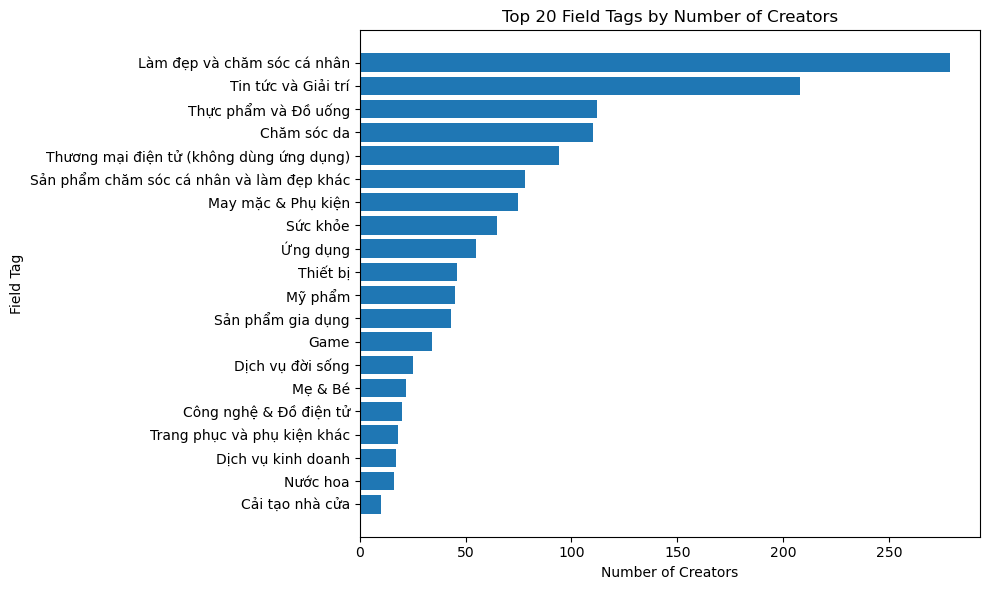

In [7]:
plt.figure(figsize=(10, 6))
plt.barh(top_field_tags["field_tag"], top_field_tags["total_creators"])
plt.title("Top 20 Field Tags by Number of Creators")
plt.xlabel("Number of Creators")
plt.ylabel("Field Tag")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Top Video Tags

In [8]:
top_video_tags = (
    video_tags_df
    .groupby("video_tag")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .sort_values("total_creators", ascending=False)
    .head(20)
)

top_video_tags

,video_tag,total_creators
4,Cuộc sống hàng ngày,276
23,Nhảy,260
15,Hướng dẫn & mẹo làm đẹp,231
14,Hát nhép,224
13,Hài kịch,177
51,Âm nhạc,115
45,Trang phục,96
48,Trò chơi điện tử,87
10,Gia đình,85
50,Tình yêu & Mối quan hệ lãng mạn,79


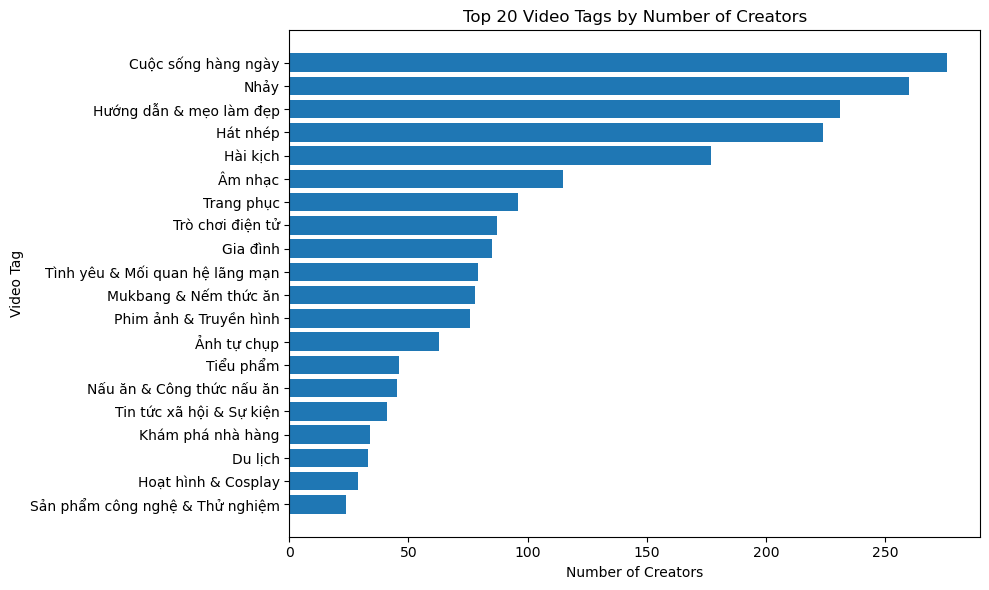

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(top_video_tags["video_tag"], top_video_tags["total_creators"])
plt.title("Top 20 Video Tags by Number of Creators")
plt.xlabel("Number of Creators")
plt.ylabel("Video Tag")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
def normalize_text(text):
    """
    Chuyển tiếng Việt có dấu về không dấu, lowercase.
    Ví dụ: 'Hướng dẫn & mẹo làm đẹp' -> 'huong dan meo lam dep'
    """
    if pd.isna(text):
        return ""
    
    text = str(text).lower().strip()
    
    text = unicodedata.normalize("NFD", text)
    text = "".join(
        char for char in text
        if unicodedata.category(char) != "Mn"
    )
    
    text = text.replace("đ", "d")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [11]:
category_mapping_vi = {
    # Beauty & Personal Care
    "huong dan meo lam dep": "Beauty & Personal Care",
    "meo lam dep": "Beauty & Personal Care",
    "lam dep": "Beauty & Personal Care",
    "trang diem": "Beauty & Personal Care",
    "my pham": "Beauty & Personal Care",
    "cham soc da": "Beauty & Personal Care",
    "cham soc ca nhan": "Beauty & Personal Care",
    "nuoc hoa": "Beauty & Personal Care",
    "duong toc": "Beauty & Personal Care",
    "toc gia": "Beauty & Personal Care",
    "tao kieu toc": "Beauty & Personal Care",
    "thiet ke cham soc toc": "Beauty & Personal Care",
    "cham soc mieng": "Beauty & Personal Care",
    "ve sinh phu nu": "Beauty & Personal Care",
    "skincare": "Beauty & Personal Care",
    "beauty": "Beauty & Personal Care",
    "makeup": "Beauty & Personal Care",

    # Fashion
    "trang phuc": "Fashion",
    "thoi trang": "Fashion",
    "may mac": "Fashion",
    "phu kien": "Fashion",
    "giay nu": "Fashion",
    "giay nam": "Fashion",
    "outfit": "Fashion",
    "quan ao": "Fashion",
    "phong cach": "Fashion",
    "fashion": "Fashion",

    # Food & Beverage
    "mukbang": "Food & Beverage",
    "nem thuc an": "Food & Beverage",
    "nau an": "Food & Beverage",
    "cong thuc nau an": "Food & Beverage",
    "thuc an": "Food & Beverage",
    "thuc pham": "Food & Beverage",
    "do uong": "Food & Beverage",
    "am thuc": "Food & Beverage",
    "do an": "Food & Beverage",
    "nha hang": "Food & Beverage",
    "kham pha nha hang": "Food & Beverage",
    "an uong": "Food & Beverage",
    "food": "Food & Beverage",
    "restaurant": "Food & Beverage",
    "cooking": "Food & Beverage",

    # Gaming
    "tro choi dien tu": "Gaming",
    "game": "Gaming",
    "gaming": "Gaming",
    "esport": "Gaming",
    "esports": "Gaming",

    # Sports & Fitness
    "the thao": "Sports & Fitness",
    "the duc": "Sports & Fitness",
    "suc khoe": "Sports & Fitness",
    "gym": "Sports & Fitness",
    "fitness": "Sports & Fitness",
    "tap luyen": "Sports & Fitness",
    "yoga": "Sports & Fitness",
    "chay bo": "Sports & Fitness",
    "bong da": "Sports & Fitness",
    "bong ro": "Sports & Fitness",
    "bong chuyen": "Sports & Fitness",
    "cau long": "Sports & Fitness",
    "tennis": "Sports & Fitness",
    "vo thuat": "Sports & Fitness",
    "boxing": "Sports & Fitness",
    "cau ca": "Sports & Fitness",
    "sport": "Sports & Fitness",
    "sports": "Sports & Fitness",

    # Entertainment
    "hai kich": "Entertainment",
    "tieu pham": "Entertainment",
    "am nhac": "Entertainment",
    "hat nhep": "Entertainment",
    "nhay": "Entertainment",
    "phim anh": "Entertainment",
    "truyen hinh": "Entertainment",
    "hoat hinh": "Entertainment",
    "cosplay": "Entertainment",
    "giai tri": "Entertainment",
    "trinh dien tai nang": "Entertainment",
    "nghe thuat": "Entertainment",
    "music": "Entertainment",
    "dance": "Entertainment",
    "comedy": "Entertainment",
    "movie": "Entertainment",

    # Lifestyle
    "cuoc song hang ngay": "Lifestyle",
    "cuoc song sinh vien": "Lifestyle",
    "doi song": "Lifestyle",
    "dong luc cuoc song": "Lifestyle",
    "lifestyle": "Lifestyle",
    "anh tu chup": "Lifestyle",
    "selfie": "Lifestyle",
    "daily": "Lifestyle",

    # Family & Relationship
    "gia dinh": "Family & Relationship",
    "tinh yeu": "Family & Relationship",
    "moi quan he": "Family & Relationship",
    "lang man": "Family & Relationship",
    "me va be": "Family & Relationship",
    "em be": "Family & Relationship",
    "be": "Family & Relationship",
    "tre em": "Family & Relationship",
    "gia dinh": "Family & Relationship",
    "family": "Family & Relationship",
    "relationship": "Family & Relationship",

    # Travel & Outdoor
    "du lich": "Travel & Outdoor",
    "kham pha": "Travel & Outdoor",
    "thien nhien": "Travel & Outdoor",
    "phong canh": "Travel & Outdoor",
    "cam trai": "Travel & Outdoor",
    "san ban": "Travel & Outdoor",
    "tourism": "Travel & Outdoor",
    "travel": "Travel & Outdoor",

    # Technology
    "san pham cong nghe": "Technology",
    "cong nghe": "Technology",
    "phan mem": "Technology",
    "ung dung": "Technology",
    "thiet bi": "Technology",
    "dien thoai": "Technology",
    "gadget": "Technology",
    "technology": "Technology",
    "tech": "Technology",

    # Home & Living
    "nha cua": "Home & Living",
    "vuon tuoc": "Home & Living",
    "san pham gia dung": "Home & Living",
    "cai tao nha cua": "Home & Living",

    # News & Social Issues
    "tin tuc": "News & Social Issues",
    "xa hoi": "News & Social Issues",
    "su kien": "News & Social Issues",
    "news": "News & Social Issues",
    "event": "News & Social Issues",

    # Education & Science
    "giao duc": "Education & Science",
    "hoc tap": "Education & Science",
    "kien thuc": "Education & Science",
    "nhan van": "Education & Science",
    "khoa hoc": "Education & Science",
    "education": "Education & Science",
    "learning": "Education & Science",
    "study": "Education & Science",

    # Business & Finance
    "kinh doanh": "Business & Finance",
    "tai chinh": "Business & Finance",
    "dich vu kinh doanh": "Business & Finance",
    "dich vu tai chinh": "Business & Finance",
    "cong viec": "Business & Finance",
    "su nghiep": "Business & Finance",
    "phat trien nghe nghiep": "Business & Finance",

    # Commerce & Review
    "thuong mai dien tu": "Commerce & Review",
    "review": "Commerce & Review",
    "danh gia": "Commerce & Review",
    "mua sam": "Commerce & Review",
    "shopping": "Commerce & Review",
    "affiliate": "Commerce & Review",
    "livestream": "Commerce & Review",

    # Pets & Animals
    "thu cung": "Pets & Animals",
    "dong vat": "Pets & Animals",
    "cho meo": "Pets & Animals",

    # Automotive
    "phuong tien giao thong": "Automotive",
    "xe co": "Automotive",
    "o to": "Automotive",
    "xe may": "Automotive",
    "moto": "Automotive",
    "car": "Automotive",
    "motorbike": "Automotive",

    # Horror / ASMR / Special
    "sieu nhien": "Horror & Mystery",
    "kinh di": "Horror & Mystery",
    "asmr": "ASMR & Sensory",
    "tham my": "ASMR & Sensory",
    "chat nhon": "ASMR & Sensory",
    "ma quai": "ASMR & Sensory",
    "nhiep anh": "Photography & Effects",
    "hieu ung dac biet": "Photography & Effects",

    # Games & Toys
    "tro choi khong phai dien tu": "Games & Toys",
    "do choi": "Games & Toys",
    "suu tam": "Games & Toys",
    "do choi suu tam": "Games & Toys"
}

In [12]:
def map_tag_to_category(tag):
    normalized_tag = normalize_text(tag)
    
    for keyword, category in sorted(
        category_mapping_vi.items(),
        key=lambda x: len(x[0]),
        reverse=True
    ):
        if keyword in normalized_tag:
            return category
    
    return "Other"

In [13]:
video_tags_df["content_category"] = video_tags_df["video_tag"].apply(map_tag_to_category)
field_tags_df["content_category"] = field_tags_df["field_tag"].apply(map_tag_to_category)

In [14]:
video_tags_df[["video_tag", "content_category"]].drop_duplicates().head(50)

,video_tag,content_category
0,Hướng dẫn & mẹo làm đẹp,Beauty & Personal Care
1,Nhảy,Entertainment
2,Hài kịch,Entertainment
4,Phim ảnh & Truyền hình,Entertainment
8,Hát nhép,Entertainment
12,Cuộc sống hàng ngày,Lifestyle
15,Nhân văn & Khoa học,Education & Science
16,Tình yêu & Mối quan hệ lãng mạn,Family & Relationship
17,Thể thao truyền thống,Sports & Fitness
18,Tin tức thể thao,Sports & Fitness


In [15]:
field_tags_df[["field_tag", "content_category"]].drop_duplicates().head(50)

,field_tag,content_category
0,Tin tức và Giải trí,Entertainment
1,Làm đẹp và chăm sóc cá nhân,Beauty & Personal Care
2,Sản phẩm chăm sóc cá nhân và làm đẹp khác,Beauty & Personal Care
3,Thực phẩm và Đồ uống,Food & Beverage
5,Chăm sóc da,Beauty & Personal Care
7,May mặc & Phụ kiện,Fashion
9,Dịch vụ kinh doanh,Business & Finance
12,Thiết bị,Technology
16,Mỹ phẩm,Beauty & Personal Care
17,Thương mại điện tử (không dùng ứng dụng),Commerce & Review


In [16]:
mapping_coverage = pd.DataFrame({
    "source": ["video_tag", "field_tag"],
    "total_tag_rows": [len(video_tags_df), len(field_tags_df)],
    "other_rows": [
        (video_tags_df["content_category"] == "Other").sum(),
        (field_tags_df["content_category"] == "Other").sum()
    ],
    "other_pct": [
        (video_tags_df["content_category"] == "Other").mean() * 100,
        (field_tags_df["content_category"] == "Other").mean() * 100
    ]
})

mapping_coverage

,source,total_tag_rows,other_rows,other_pct
0,video_tag,2427,0,0.0
1,field_tag,1434,0,0.0


In [17]:
other_video_tags = (
    video_tags_df[video_tags_df["content_category"] == "Other"]
    .groupby("video_tag")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .sort_values("total_creators", ascending=False)
)

other_video_tags.head(50)

,video_tag,total_creators


In [18]:
other_field_tags = (
    field_tags_df[field_tags_df["content_category"] == "Other"]
    .groupby("field_tag")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .sort_values("total_creators", ascending=False)
)

other_field_tags.head(50)

,field_tag,total_creators


In [19]:
other_video = (
    video_tags_df[video_tags_df["content_category"] == "Other"]
    .groupby("video_tag")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .rename(columns={"video_tag": "tag"})
)

other_video["tag_source"] = "video_tag"


other_field = (
    field_tags_df[field_tags_df["content_category"] == "Other"]
    .groupby("field_tag")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .rename(columns={"field_tag": "tag"})
)

other_field["tag_source"] = "field_tag"


other_tags_all = pd.concat(
    [other_video, other_field],
    ignore_index=True
).sort_values("total_creators", ascending=False)

other_tags_all.head(100)

,tag,total_creators,tag_source


In [20]:
creator_category_df = pd.concat(
    [
        video_tags_df[["id", "name", "video_tag", "content_category"]]
        .rename(columns={"video_tag": "tag"})
        .assign(tag_source="video_tag"),

        field_tags_df[["id", "name", "field_tag", "content_category"]]
        .rename(columns={"field_tag": "tag"})
        .assign(tag_source="field_tag")
    ],
    ignore_index=True
).drop_duplicates()

creator_category_df.head()

,id,name,tag,content_category,tag_source
0,.bepdiiday._,Bẹp bẹp,Hướng dẫn & mẹo làm đẹp,Beauty & Personal Care,video_tag
1,.bepdiiday._,Bẹp bẹp,Nhảy,Entertainment,video_tag
2,.thanhnhan204,Thanh Nhàn,Hài kịch,Entertainment,video_tag
3,.thanhnhan204,Thanh Nhàn,Hướng dẫn & mẹo làm đẹp,Beauty & Personal Care,video_tag
4,0cgnp,Không có gì ngoài PHIM,Phim ảnh & Truyền hình,Entertainment,video_tag


In [21]:
missing_category_creators = df[
    ~df["id"].isin(creator_category_df["id"])
][["id", "name"]].copy()

missing_category_creators["tag"] = "No tag"
missing_category_creators["content_category"] = "Uncategorized"
missing_category_creators["tag_source"] = "no_tag"

creator_category_df = pd.concat(
    [creator_category_df, missing_category_creators],
    ignore_index=True
)

creator_category_df = creator_category_df.drop_duplicates()

creator_category_df["id"].nunique()

1149

In [22]:
category_summary = (
    creator_category_df
    .groupby("content_category")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .sort_values("total_creators", ascending=True)
)

category_summary

,content_category,total_creators
13,Horror & Mystery,2
0,ASMR & Sensory,3
1,Automotive,9
17,Photography & Effects,10
10,Games & Toys,27
16,Pets & Animals,28
5,Education & Science,31
21,Uncategorized,33
3,Business & Finance,37
20,Travel & Outdoor,38


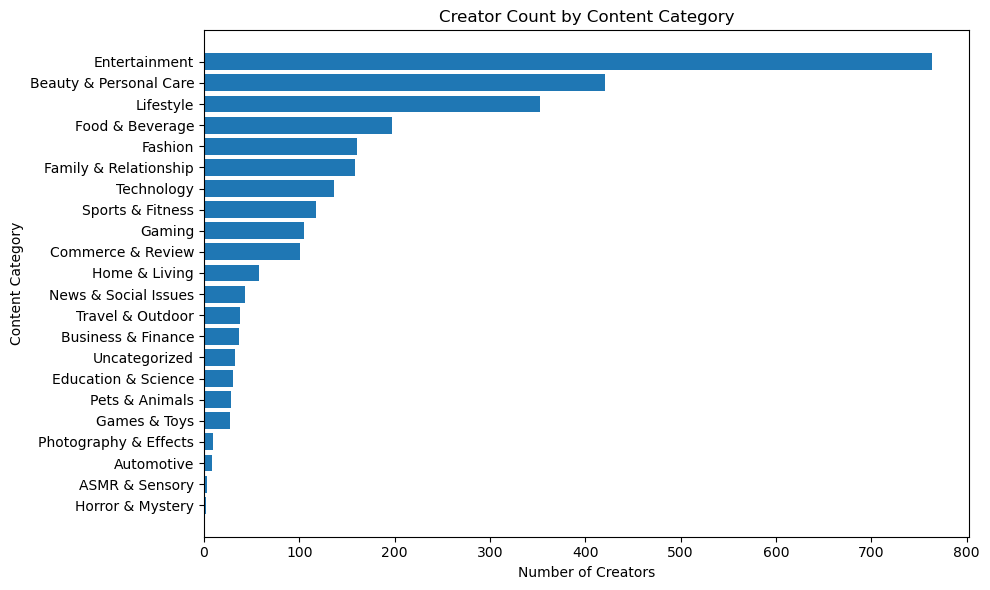

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(category_summary["content_category"], category_summary["total_creators"])
plt.title("Creator Count by Content Category")
plt.xlabel("Number of Creators")
plt.ylabel("Content Category")
plt.tight_layout()
plt.show()

In [24]:
creator_category_performance = creator_category_df.merge(
    df,
    on=["id", "name"],
    how="left"
)

creator_category_performance.head()

,id,name,tag,content_category,tag_source,country,collab_score,broadcast_score,commerce_score,followers_num,median_views_num,engagement_pct,price_num,field_tags,video_tags,cpv,view_rate_pct,creator_segment,price_tier,potential_group
0,.bepdiiday._,Bẹp bẹp,Hướng dẫn & mẹo làm đẹp,Beauty & Personal Care,video_tag,Việt Nam,79.6,93.7,NaN,1700000.0,537400.0,5.42,10000000.0,NaN,"Hướng dẫn & mẹo làm đẹp, Nhảy",18.608113,31.611765,Mega,Medium,Cost-efficient
1,.bepdiiday._,Bẹp bẹp,Nhảy,Entertainment,video_tag,Việt Nam,79.6,93.7,NaN,1700000.0,537400.0,5.42,10000000.0,NaN,"Hướng dẫn & mẹo làm đẹp, Nhảy",18.608113,31.611765,Mega,Medium,Cost-efficient
2,.thanhnhan204,Thanh Nhàn,Hài kịch,Entertainment,video_tag,Việt Nam,88.4,95.8,NaN,645200.0,416900.0,3.47,9933033.0,NaN,"Hài kịch, Hướng dẫn & mẹo làm đẹp",23.825937,64.615623,Macro,Medium,Cost-efficient
3,.thanhnhan204,Thanh Nhàn,Hướng dẫn & mẹo làm đẹp,Beauty & Personal Care,video_tag,Việt Nam,88.4,95.8,NaN,645200.0,416900.0,3.47,9933033.0,NaN,"Hài kịch, Hướng dẫn & mẹo làm đẹp",23.825937,64.615623,Macro,Medium,Cost-efficient
4,0cgnp,Không có gì ngoài PHIM,Phim ảnh & Truyền hình,Entertainment,video_tag,Việt Nam,80.4,97.9,NaN,271350.0,102500.0,16.67,7452213.0,NaN,Phim ảnh & Truyền hình,72.704517,37.774093,Mid-tier,Medium,General / Low Priority


In [25]:
category_performance = (
    creator_category_performance
    .groupby("content_category")
    .agg(
        total_creators=("id", "nunique"),
        avg_followers=("followers_num", "mean"),
        avg_median_views=("median_views_num", "mean"),
        avg_engagement=("engagement_pct", "mean"),
        median_price=("price_num", "median"),
        median_cpv=("cpv", "median"),
        avg_broadcast_score=("broadcast_score", "mean"),
        avg_commerce_score=("commerce_score", "mean"),
        avg_collab_score=("collab_score", "mean")
    )
    .reset_index()
    .sort_values("total_creators", ascending=False)
)

category_performance

,content_category,total_creators,avg_followers,avg_median_views,avg_engagement,median_price,median_cpv,avg_broadcast_score,avg_commerce_score,avg_collab_score
6,Entertainment,764,1.927006e+06,333091.038560,7.703188,7000000.0,42.342978,94.054107,95.120588,79.332229
2,Beauty & Personal Care,421,2.111599e+06,351903.668734,6.428859,9319688.0,48.385676,94.580477,95.093333,80.953004
14,Lifestyle,353,1.906399e+06,303833.549223,6.414339,7957359.0,45.246693,93.852076,94.163636,79.125457
9,Food & Beverage,197,1.946863e+06,408192.114695,5.086756,10000000.0,40.049808,93.981250,93.904000,78.555018
8,Fashion,161,2.067072e+06,394129.591133,6.783251,8801191.0,48.875050,95.050585,94.270588,80.684729
7,Family & Relationship,158,1.914643e+06,390181.061538,5.384949,10000000.0,43.301260,93.660526,94.533333,79.705641
19,Technology,136,2.036881e+06,295332.919255,5.530963,9319688.0,48.178821,94.712174,93.170370,80.470186
18,Sports & Fitness,118,2.084321e+06,292501.481481,5.232815,8113979.0,47.687319,93.821429,94.512000,80.016923
11,Gaming,105,2.271216e+06,408745.867769,6.289752,6000000.0,34.089960,94.580769,94.651852,82.637083
4,Commerce & Review,101,2.277113e+06,375345.965347,5.651584,10000000.0,40.528376,94.097468,95.242105,80.235149


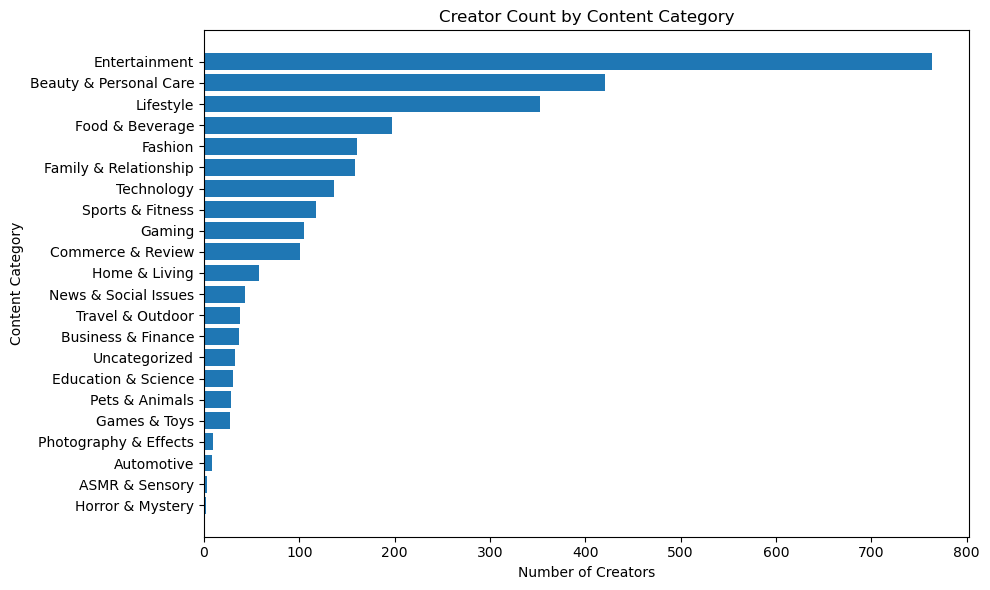

In [26]:
category_summary = (
    creator_category_df
    .groupby("content_category")
    .agg(total_creators=("id", "nunique"))
    .reset_index()
    .sort_values("total_creators", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(category_summary["content_category"], category_summary["total_creators"])
plt.title("Creator Count by Content Category")
plt.xlabel("Number of Creators")
plt.ylabel("Content Category")
plt.tight_layout()
plt.show()

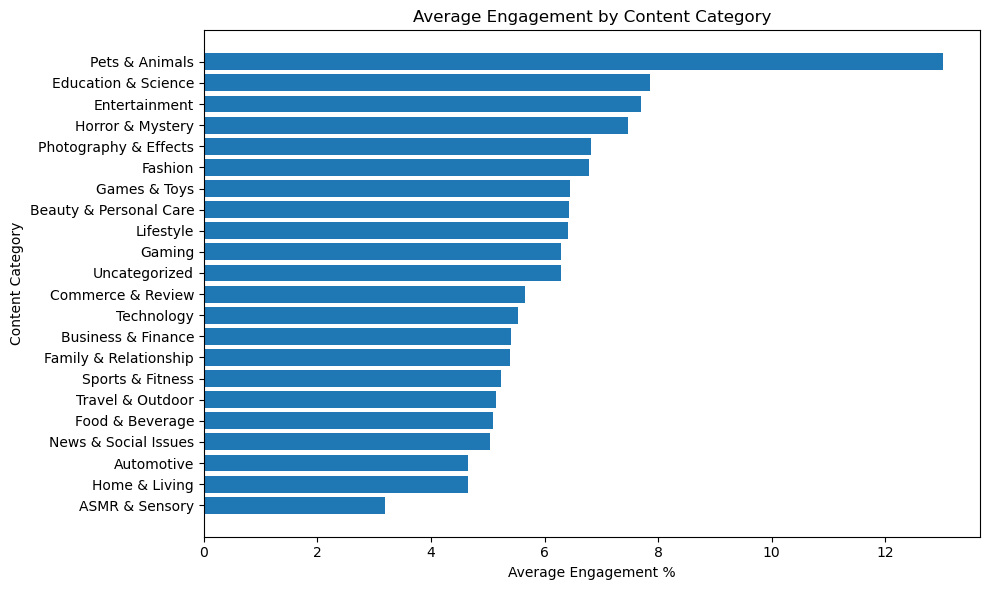

In [27]:
engagement_by_category = category_performance.sort_values("avg_engagement", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(engagement_by_category["content_category"], engagement_by_category["avg_engagement"])
plt.title("Average Engagement by Content Category")
plt.xlabel("Average Engagement %")
plt.ylabel("Content Category")
plt.tight_layout()
plt.show()

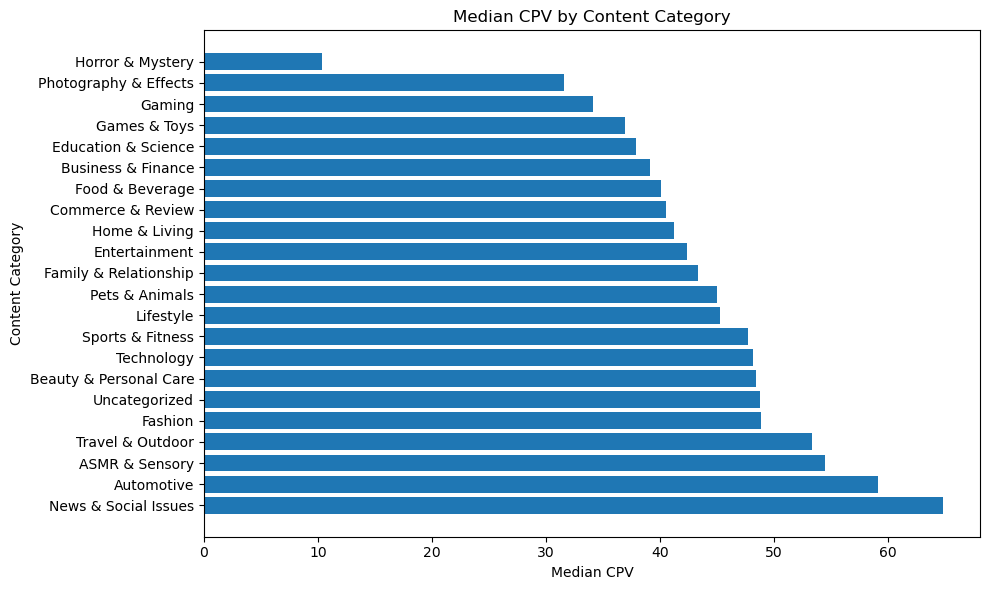

In [28]:
cpv_by_category = category_performance.sort_values("median_cpv", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(cpv_by_category["content_category"], cpv_by_category["median_cpv"])
plt.title("Median CPV by Content Category")
plt.xlabel("Median CPV")
plt.ylabel("Content Category")
plt.tight_layout()
plt.show()

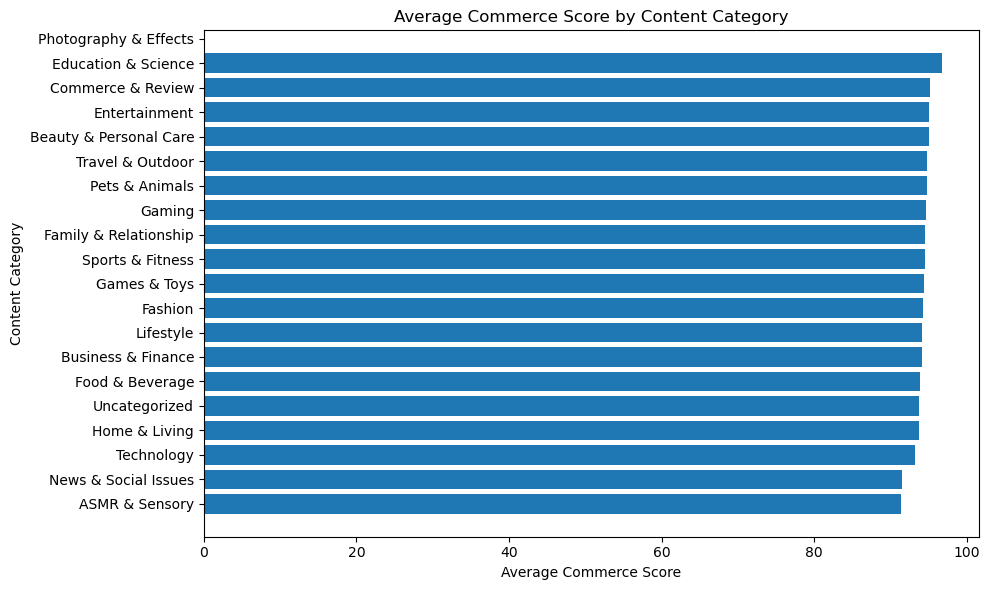

In [29]:
commerce_by_category = category_performance.sort_values("avg_commerce_score", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(commerce_by_category["content_category"], commerce_by_category["avg_commerce_score"])
plt.title("Average Commerce Score by Content Category")
plt.xlabel("Average Commerce Score")
plt.ylabel("Content Category")
plt.tight_layout()
plt.show()

In [30]:
top_creators_by_category = (
    creator_category_performance[
        creator_category_performance["cpv"].notna()
    ]
    .sort_values(
        ["content_category", "cpv", "median_views_num", "engagement_pct"],
        ascending=[True, True, False, False]
    )
    .groupby("content_category")
    .head(10)
    [
        [
            "content_category",
            "name",
            "followers_num",
            "median_views_num",
            "engagement_pct",
            "price_num",
            "cpv",
            "broadcast_score",
            "commerce_score",
            "collab_score",
            "potential_group"
        ]
    ]
)

top_creators_by_category

,content_category,name,followers_num,median_views_num,engagement_pct,price_num,cpv,broadcast_score,commerce_score,collab_score,potential_group
1771,ASMR & Sensory,Quyển Sách Nhỏ,1200000.0,216100.0,2.275,10000000.0,46.274873,NaN,90.8,88.95,General / Low Priority
1772,ASMR & Sensory,Quyển Sách Nhỏ,1200000.0,216100.0,2.275,10000000.0,46.274873,NaN,90.8,88.95,General / Low Priority
665,ASMR & Sensory,Gà Rán Chiên Giòn,3900000.0,73400.0,4.620,4000000.0,54.495913,99.30,NaN,92.80,General / Low Priority
666,ASMR & Sensory,Gà Rán Chiên Giòn,3900000.0,73400.0,4.620,4000000.0,54.495913,99.30,NaN,92.80,General / Low Priority
1474,ASMR & Sensory,NgaChan Asmr,3500000.0,76500.0,2.650,15000000.0,196.078431,NaN,92.0,86.30,General / Low Priority
...,...,...,...,...,...,...,...,...,...,...,...
3872,Uncategorized,Dũng Gee,4700000.0,1400000.0,3.910,21447134.0,15.319381,91.95,NaN,76.30,Cost-efficient
3893,Uncategorized,🇫🇷Will in Vietnam🇻🇳,3400000.0,267200.0,4.000,4157776.0,15.560539,95.80,NaN,77.30,Cost-efficient
3883,Uncategorized,Quan không gờ,4700000.0,751600.0,3.170,12532369.0,16.674254,90.20,91.2,85.30,Cost-efficient
3889,Uncategorized,Thuận Ròm,1500000.0,534900.0,2.085,9801729.0,18.324414,NaN,NaN,75.80,Cost-efficient


In [31]:
creator_category_df.to_csv(
    "../data/cleaned/creator_content_category.csv",
    index=False,
    encoding="utf-8-sig"
)

video_tags_df.to_csv(
    "../data/cleaned/creator_video_tags.csv",
    index=False,
    encoding="utf-8-sig"
)

field_tags_df.to_csv(
    "../data/cleaned/creator_field_tags.csv",
    index=False,
    encoding="utf-8-sig"
)

other_tags_all.to_csv(
    "../data/cleaned/unmapped_other_tags.csv",
    index=False,
    encoding="utf-8-sig"
)

category_performance.to_csv(
    "../data/cleaned/category_performance_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Export completed.")

Export completed.
